# Tutorial: Bayesian Statistics Lab: Priors, Model Selection, and Posterior Inference

Federico Cerutti <federico.cerutti@unibs.it>

The notes are released with CC0. The code is MIT.

**Format of this notebook.** This notebook is designed as a self-guided lab. The code cells are intentionally compact and should be treated as the validated reference implementation. The teaching material therefore lives in the markdown: read the text first, inspect the code second, and only then run the cell.



**Useful references for students who want a formal API reference**
- [PyMC documentation](https://www.pymc.io/projects/docs/en/stable/learn.html)
- [ArviZ documentation](https://python.arviz.org/en/stable/)
- [SciPy statistical tests](https://docs.scipy.org/doc/scipy/reference/stats.html)
- [statsmodels power analysis](https://www.statsmodels.org/stable/stats.html#power-and-sample-size)

**Main take-away for this lab**
- In the examples below, Bayesian analysis is more informative for decision making because it returns full uncertainty distributions and directly interpretable probabilities, not only a reject / fail-to-reject decision.


## 0. Environment setup and reading strategy


- The first code cell installs missing packages in a Colab-friendly way.
- The second code cell imports the libraries, fixes the global seed, and creates the random number generator used throughout the notebook.

As you read the import cell, classify the libraries by role:
- **classical statistics** (`scipy`, `statsmodels`),
- **Bayesian modeling and diagnostics** (`pymc`, `arviz`),
- **data handling and plotting** (`pandas`, `numpy`, `matplotlib`).


In [1]:
# Colab-friendly install cell.
# It only installs packages that are missing in the current runtime.
import subprocess
import sys

required = ["pymc", "arviz", "statsmodels"]
# ArviZ — works hand-in-hand with PyMC. After sampling, ArviZ gives you summaries (az.summary()), diagnostic plots, and model comparison (az.compare() with LOO). Think of it as the "results viewer" for PyMC.
# PyMC — this is the most important library to understand. It lets you define probabilistic models and sample from posteriors using NUTS (a modern MCMC algorithm). You'll see the with pm.Model() pattern everywhere.

import importlib.util
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print({"missing_before_install": missing, "required": required})


{'missing_before_install': [], 'required': ['pymc', 'arviz', 'statsmodels']}


In [2]:
from __future__ import annotations

import os
import random
import warnings
from math import lgamma

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats
from scipy.stats import beta as beta_dist, gamma as gamma_dist
from statsmodels.stats.power import TTestIndPower

warnings.filterwarnings("ignore")
az.style.use("arviz-whitegrid")


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [3]:
# One global seed for deterministic notebook output.
SEED = 42

# SET SEED FOR OS ENVIRONMENT VARIABLES
os.environ["PYTHONHASHSEED"] = str(SEED)

# SET SEED FOR PYTHON'S BUILT-IN RANDOM MODULE
random.seed(SEED) # random.seed(SEED) sets the seed for Python's built-in random number generator, which is used by the random module. This ensures that any random operations performed using this module will produce the same results each time the code is run, as long as the seed is set to the same value.

# SET SEED FOR NUMPY'S RANDOM NUMBER GENERATOR (2 WAYS)
np.random.seed(SEED) # np.random.seed(SEED) sets the seed for NumPy's random number generator, which is used for any random operations performed using NumPy (e.g., np.random.rand, np.random.normal). This ensures that any random numbers generated by NumPy will be the same each time the code is run, as long as the seed is set to the same value.
RNG = np.random.default_rng(SEED) # RNG = np.random.default_rng(SEED) creates a new random number generator instance using NumPy's newer random API. 
# This is a more modern and flexible way to generate random numbers compared to the older np.random functions. By passing the seed to default_rng, you ensure that this specific generator will produce the same sequence of random numbers each time the code is run, as long as the seed is the same.

print({"seed": SEED})

{'seed': 42}


## 3. Continuous measurements: PyMC posterior sampling for positive rates

We now repeat the same question from Section 2 on a continuous scale: do two systems have the same positive rate, or not?

To keep the prior simple, we use an exponential likelihood with a Gamma prior on the rate:

rate ~ Gamma(alpha, beta)
y_i | rate ~ Exponential(rate)

A Gamma prior is handy here because it only allows positive rates. In the shape/rate form used by PyMC:
- mean = alpha / beta
- variance = alpha / beta^2

PyMC samples the posterior with NUTS, and ArviZ turns the draws into summaries and plots. That is the workflow you want to reuse on harder models.

**Before running the next cell**
- Notice that larger rate means shorter average response time.
- Find the shared-rate model and the separate-rate model.
- Predict whether the two systems will look distinguishable.


### Gamma and Exponential primer

For positive measurements, two distributions are worth knowing.

- The Exponential distribution models waiting times. Its rate parameter `lambda` controls how quickly the curve decays: larger `lambda` means shorter typical times.
- The Gamma distribution lives on positive values only, so it is a natural prior for a positive rate. In the shape/rate form used here, its mean is `alpha / beta` and its variance is `alpha / beta^2`.

Intuition for the Bayesian workflow:
- The **prior** says which rates were plausible before seeing the data.
- The **likelihood** scores each candidate rate by how well it explains the observed sample. It is not a probability over `lambda`; it is a support curve for the data given `lambda`.
- The **posterior** combines both: prior belief plus evidence from the data.

The next cell shows this on a tiny toy example.


In [4]:
# Tiny toy example to build intuition for the prior, likelihood, and posterior.
toy_times = np.array([0.35, 0.80, 0.40, 1.10, 0.65]) # These could represent observed times for a certain process (e.g., time to complete a task) that we are trying to model with an exponential distribution. The goal is to infer the rate parameter (lambda) of the exponential distribution based on these observed times, using Bayesian inference.
toy_n = len(toy_times)
toy_sum = float(toy_times.sum()) # The sum of the observed times, which is a sufficient statistic for the exponential distribution when using a conjugate prior. This will be used in the likelihood function and in updating the posterior distribution.

# LIKELIHOOD: The likelihood function for the exponential distribution given the observed data is proportional to lambda^n * exp(-lambda * sum_of_times). This represents how likely the observed data is for different values of lambda. We will compute this likelihood over a grid of lambda values to visualize it and to use it in the Bayesian updating process.
lambda_grid = np.linspace(0.05, 3.0, 600)# lambda is between 0.05 and 3.0, with 600 points in between. This grid will be used to evaluate the likelihood and the posterior distribution over a range of possible lambda values.
likelihood = lambda_grid**toy_n * np.exp(-lambda_grid * toy_sum)
# The likelihood is computed using the formula for the exponential distribution's likelihood given the observed data. 
# It is proportional to lambda^n * exp(-lambda * sum_of_times), where n is the number of observations and sum_of_times is the total time observed. This gives us a function that we can evaluate at each point in lambda_grid to see how likely the observed data is for different values of lambda.
from scipy.integrate import trapezoid
likelihood = likelihood / trapezoid(likelihood, lambda_grid)
# We normalize the likelihood by dividing it by the integral of the likelihood over the lambda grid (computed using np.trapz). This ensures that the likelihood function integrates to 1 over the range of lambda values, making it a proper probability density function. Normalizing the likelihood is important for visualizing it and for combining it with the prior to get the posterior distribution in a Bayesian framework.


In [5]:
# PRIOR: The Gamma distribution is a common choice for the prior distribution of the rate parameter (lambda) of an exponential distribution because it is conjugate to the exponential likelihood. This means that if we choose a Gamma prior, the posterior distribution will also be a Gamma distribution, which makes the math simpler and allows us to easily update our beliefs about lambda after observing the data.
prior_weak = gamma_dist.pdf(lambda_grid, 2.0, scale=1 / 2.0)
prior_skeptical = gamma_dist.pdf(lambda_grid, 8.0, scale=1 / 8.0)

In [6]:
# POSTERIOR: The posterior distribution is computed by multiplying the likelihood by the prior and then normalizing. Since we are using a conjugate prior (Gamma) for an exponential likelihood, the posterior will also be a Gamma distribution with updated parameters. The parameters of the posterior can be derived from the prior parameters and the sufficient statistics of the data (n and sum of times).
posterior_weak = gamma_dist.pdf(lambda_grid, 2.0 + toy_n, scale=1 / (2.0 + toy_sum))
posterior_skeptical = gamma_dist.pdf(lambda_grid, 8.0 + toy_n, scale=1 / (8.0 + toy_sum))

In [7]:
toy_summary = pd.DataFrame(
    {
        "quantity": ["sample mean", "MLE rate", "posterior mean (Gamma 2,2)", "posterior mean (Gamma 8,8)", "MAP (Gamma 2,2)", "MAP (Gamma 8,8)"],
        "value": [toy_times.mean(), toy_n / toy_sum, (2.0 + toy_n) / (2.0 + toy_sum), (8.0 + toy_n) / (8.0 + toy_sum), (2.0 + toy_n - 1) / (2.0 + toy_sum), (8.0 + toy_n - 1) / (8.0 + toy_sum)],
    }
)

display(toy_summary.round(3))


,quantity,value
0,sample mean,0.660
1,MLE rate,1.515
2,"posterior mean (Gamma 2,2)",1.321
3,"posterior mean (Gamma 8,8)",1.150
4,"MAP (Gamma 2,2)",1.132
5,"MAP (Gamma 8,8)",1.062


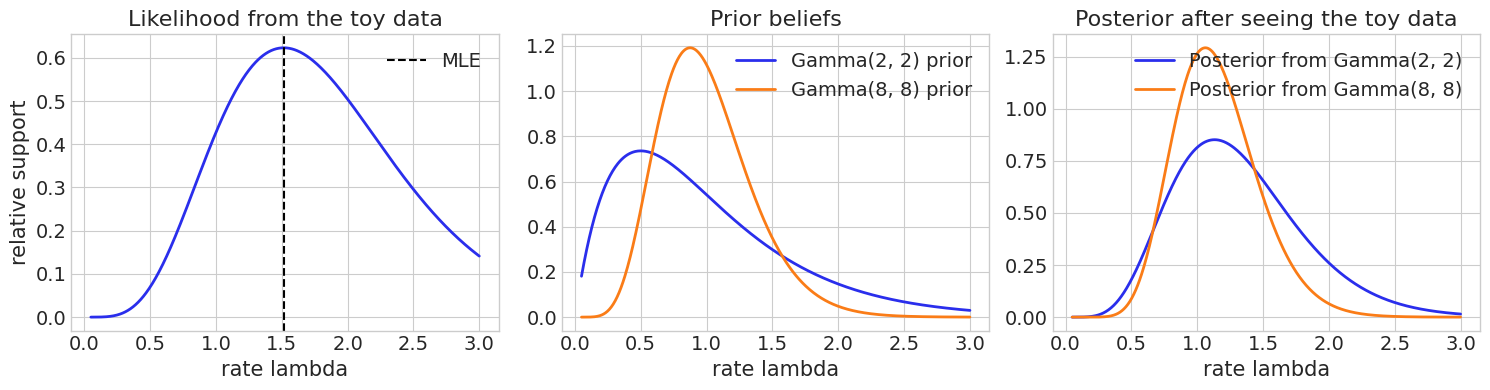

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
axes[0].plot(lambda_grid, likelihood, color="C0", linewidth=2)
axes[0].axvline(toy_n / toy_sum, color="black", linestyle="--", label="MLE")
axes[0].set_title("Likelihood from the toy data")
axes[0].set_xlabel("rate lambda")
axes[0].set_ylabel("relative support")
axes[0].legend()

axes[1].plot(lambda_grid, prior_weak, label="Gamma(2, 2) prior", linewidth=2)
axes[1].plot(lambda_grid, prior_skeptical, label="Gamma(8, 8) prior", linewidth=2)
axes[1].set_title("Prior beliefs")
axes[1].set_xlabel("rate lambda")
axes[1].legend()

axes[2].plot(lambda_grid, posterior_weak, label="Posterior from Gamma(2, 2)", linewidth=2)
axes[2].plot(lambda_grid, posterior_skeptical, label="Posterior from Gamma(8, 8)", linewidth=2)
axes[2].set_title("Posterior after seeing the toy data")
axes[2].set_xlabel("rate lambda")
axes[2].legend()

plt.tight_layout();